<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Sistemas%20Inteligentes%20II/BreastCancerWisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Josue Santana Robledo Corona

In [ ]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
!curl -L -o BreastCancerWisconsin.csv https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/BreastCancerWisconsin.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  122k  100  122k    0     0   693k      0 --:--:-- --:--:-- --:--:--  690k


In [ ]:
dataset_1 = pd.read_csv('BreastCancerWisconsin.csv')
dataset_1.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
dataset_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
dataset_1.isin(['?', 'NA', 'N/A', '-']).sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
dataset_1 = dataset_1.drop(columns=['Unnamed: 32'])

In [ ]:
dataset_1.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
print(dataset_1.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
x = np.asanyarray(dataset_1.drop(columns=['id','diagnosis']))
y = np.asanyarray(dataset_1['diagnosis'].map({"M":1,"B":0}))

x = StandardScaler().fit_transform(x)

print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2,stratify=y)

In [ ]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(16, activation='tanh', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(16, activation='tanh'))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(loss='binary_crossentropy',
                optimizer=keras.optimizers.Adam(),
                metrics=[keras.metrics.MAE, keras.metrics.R2Score])
  return  model

In [ ]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dataset_1 = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=500,
                    validation_data=(xtest, ytest), verbose=1)

result = model.evaluate(xtest, ytest)
print(result)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - loss: 0.4084 - mean_absolute_error: 0.3127 - r2_score: 0.4769 - val_loss: 0.3167 - val_mean_absolute_error: 0.2538 - val_r2_score: 0.6337
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3534 - mean_absolute_error: 0.2726 - r2_score: 0.5728 - val_loss: 0.2751 - val_mean_absolute_error: 0.2237 - val_r2_score: 0.6976
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.3214 - mean_absolute_error: 0.2514 - r2_score: 0.6107 - val_loss: 0.2427 - val_mean_absolute_error: 0.1997 - val_r2_score: 0.7446
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2870 - mean_absolute_error: 0.2261 - r2_score: 0.6663 - val_loss: 0.2151 - val_mean_absolute_error: 0.1785 - val_r2_score: 0.7821
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2637 - mean_absolute_error: 0.2066 - r2_score: 0.7030 - val_loss: 0.1922 - val_mean_absolute_error: 0.1606 - val_r2_score: 0.8114
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

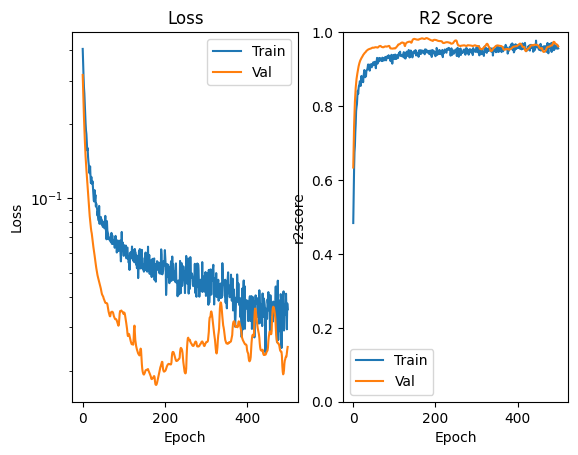

In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()

plot_history(history_dataset_1)

In [ ]:
gist_df=pd.DataFrame(history_dataset_1.history)
##gist_df.to_csv('history.csv',index=False)
print(gist_df)

         loss  mean_absolute_error  r2_score  val_loss  \
0    0.403744             0.309871  0.483468  0.316658   
1    0.353960             0.273452  0.564202  0.275102   
2    0.313806             0.246084  0.628220  0.242738   
3    0.282597             0.221986  0.674886  0.215078   
4    0.267038             0.208547  0.691995  0.192224   
..        ...                  ...       ...       ...   
495  0.041111             0.020227  0.955697  0.022863   
496  0.035158             0.019654  0.959624  0.022857   
497  0.029500             0.018653  0.964805  0.023668   
498  0.037550             0.020355  0.955308  0.024381   
499  0.035535             0.021934  0.955918  0.025022   

     val_mean_absolute_error  val_r2_score  
0                   0.253812      0.633688  
1                   0.223674      0.697551  
2                   0.199684      0.744589  
3                   0.178493      0.782134  
4                   0.160553      0.811392  
..                       ...     

In [ ]:
result = model.evaluate(xtest, ytest)
print(result)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0402 - mean_absolute_error: 0.0248 - r2_score: 0.9330
[0.02502199076116085, 0.015942426398396492, 0.9615030288696289]
